# Hands‑On Data Cleaning Notebook

*Generated: 2025-11-06 11:15*

This notebook guides you through a rigorous cleaning pass for your **capstone dataset**. Fill the TODOs and run cells in order. Keep this under version control (commits with meaningful messages).

## 1. DataSet Configuration
- Make sure your csv file(s) are in `data/`.
- Update `dataset_path` below.
- Modify/Update configurations here to set the base

In [1]:
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

dataset_path = "../data/suicides.csv"
dataset_maxrows = 200

df = pd.read_csv(dataset_path)
#df.options.max(dataset_maxrows)  -- example of configuration


df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4422 entries, 0 to 4421
Data columns (total 4 columns):
 #   Column                                                       Non-Null Count  Dtype  
---  ------                                                       --------------  -----  
 0   Entity                                                       4422 non-null   object 
 1   Code                                                         4290 non-null   object 
 2   Year                                                         4422 non-null   int64  
 3   Age-standardized death rate from self-harm among both sexes  4422 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 138.3+ KB


## 2) DataSet Analysis 
- Updating existing column names from raw dataset for uniformity across datasets
- Performing head(), info() operations to get an overview of data
- Convert column types wherever needed
- Converting all string to small case for efficient data operations

In [2]:
df.dtypes

Entity                                                          object
Code                                                            object
Year                                                             int64
Age-standardized death rate from self-harm among both sexes    float64
dtype: object

In [3]:
df.columns = ["country_name","country_code","year","suicide_data"]

df["country_name"] = df["country_name"].astype("string")
df["country_code"] = df["country_code"].astype("string")

df["country_name"] = df["country_name"].str.lower()
df["country_code"] = df["country_code"].str.lower()
df["suicide_data"] = df["suicide_data"].round(2)

#df.head()           #shows first 5 records with header
#df.info()            #gives information about the column names along with their datatypes
#df                   #shows first 5 and last 5 data from datasets
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4422 entries, 0 to 4421
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_name  4422 non-null   string 
 1   country_code  4290 non-null   string 
 2   year          4422 non-null   int64  
 3   suicide_data  4422 non-null   float64
dtypes: float64(1), int64(1), string(2)
memory usage: 138.3 KB


## 3) Missing Data: Identify → Decide → Apply
- Find empty records

In [4]:
# Identify missing data
missing_counts = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing_counts / len(df) * 100).round(2)
missing_report = pd.DataFrame({"missing_count": missing_counts, "missing_pct": missing_pct})

missing_report

,missing_count,missing_pct
country_code,132,2.99
country_name,0,0.00
year,0,0.00
suicide_data,0,0.00


In [5]:
# show the missing rows

bool_series = pd.isnull(df["country_code"])
missing_country_code_data = df[bool_series]

missing_country_code_data





,country_name,country_code,year,suicide_data
22,africa,<NA>,2000,10.09
23,africa,<NA>,2001,10.01
24,africa,<NA>,2002,10.02
25,africa,<NA>,2003,10.01
26,africa,<NA>,2004,9.92
...,...,...,...,...
3691,south america,<NA>,2017,6.64
3692,south america,<NA>,2018,6.55
3693,south america,<NA>,2019,6.55
3694,south america,<NA>,2020,6.26


In [6]:
unique_countries = df['country_name'].unique()
unique_country_code = df['country_code'].unique()

#unique_countries
#unique_country_code

missing_country_code_data


,country_name,country_code,year,suicide_data
22,africa,<NA>,2000,10.09
23,africa,<NA>,2001,10.01
24,africa,<NA>,2002,10.02
25,africa,<NA>,2003,10.01
26,africa,<NA>,2004,9.92
...,...,...,...,...
3691,south america,<NA>,2017,6.64
3692,south america,<NA>,2018,6.55
3693,south america,<NA>,2019,6.55
3694,south america,<NA>,2020,6.26


In [7]:
missing_country_code_data["country_name"].unique()

<StringArray>
['africa', 'asia', 'europe', 'north america', 'oceania', 'south america']
Length: 6, dtype: string

## 4) Remove inconsitent data
- remove data that has empty country code

In [8]:
df = df.dropna(subset=["country_code"])

df

,country_name,country_code,year,suicide_data
0,afghanistan,afg,2000,7.20
1,afghanistan,afg,2001,7.28
2,afghanistan,afg,2002,7.12
3,afghanistan,afg,2003,7.05
4,afghanistan,afg,2004,7.03
...,...,...,...,...
4417,zimbabwe,zwe,2017,23.66
4418,zimbabwe,zwe,2018,24.73
4419,zimbabwe,zwe,2019,23.76
4420,zimbabwe,zwe,2020,23.61


In [9]:
missing_counts_1 = df.isnull().sum().sort_values(ascending=False)
missing_pct_1 = (missing_counts_1 / len(df) * 100).round(2)
missing_report_1 = pd.DataFrame({"missing_count": missing_counts_1, "missing_pct": missing_pct_1})

missing_report_1

,missing_count,missing_pct
country_name,0,0.0
country_code,0,0.0
year,0,0.0
suicide_data,0,0.0


In [10]:
unique_countries_1 = df['country_name'].unique()
unique_country_code_1 = df['country_code'].unique()

unique_countries_1


<StringArray>
[        'afghanistan',             'albania',             'algeria',
             'andorra',              'angola', 'antigua and barbuda',
           'argentina',             'armenia',           'australia',
             'austria',
 ...
       'united states',             'uruguay',          'uzbekistan',
             'vanuatu',           'venezuela',             'vietnam',
               'world',               'yemen',              'zambia',
            'zimbabwe']
Length: 195, dtype: string

In [11]:

unique_country_code_1

<StringArray>
[     'afg',      'alb',      'dza',      'and',      'ago',      'atg',
      'arg',      'arm',      'aus',      'aut',
 ...
      'usa',      'ury',      'uzb',      'vut',      'ven',      'vnm',
 'owid_wrl',      'yem',      'zmb',      'zwe']
Length: 195, dtype: string

## 5) Remove Duplicate Records

In [12]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows found:", duplicate_count)

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed. New shape:", df.shape)
else:
    print("No duplicate rows detected.")


Duplicate rows found: 0
No duplicate rows detected.


## 6) Detect Outliers with Visualizations

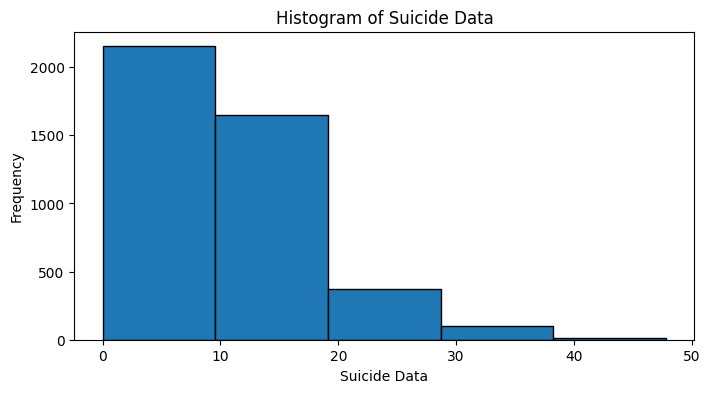

In [13]:
# HISTOGRAMS (one plot per numeric column)
plt.figure(figsize=(8, 4))
plt.hist(df["suicide_data"], bins=5, edgecolor="black")
plt.title("Histogram of Suicide Data")
plt.xlabel("Suicide Data")
plt.ylabel("Frequency")
plt.show()


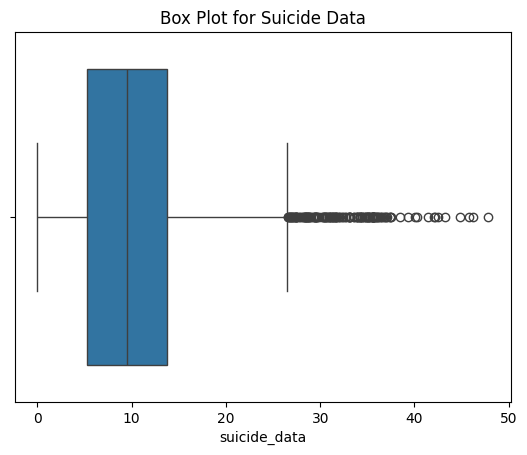

In [14]:
# BOX PLOTS (one plot per numeric column)
sns.boxplot(x=df['suicide_data'])
plt.title("Box Plot for Suicide Data")
plt.show()


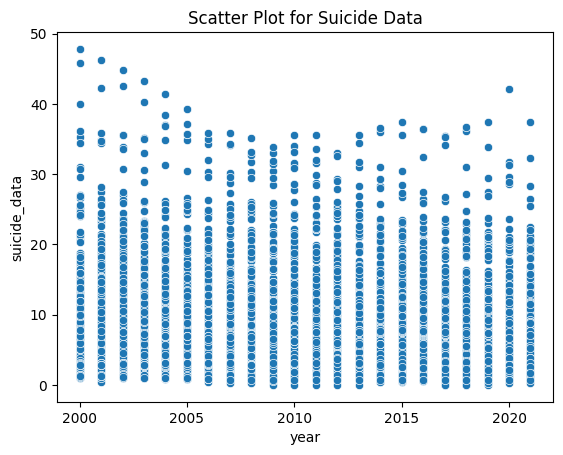

In [15]:
# Scatter Plot
sns.scatterplot(x=df['year'], y=df['suicide_data'])
plt.title("Scatter Plot for Suicide Data")
plt.show()

In [16]:

# Calculate Q1, Q3, and IQR
Q1 = df["suicide_data"].quantile(0.25)
Q3 = df["suicide_data"].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Detect outliers
outliers = df[(df["suicide_data"] < lower_bound) | (df["suicide_data"] > upper_bound)]

print("Outliers:")
print(outliers)

Outliers:
     country_name country_code  year  suicide_data
374       belarus          blr  2000         35.31
375       belarus          blr  2001         34.93
376       belarus          blr  2002         35.51
377       belarus          blr  2003         35.08
378       belarus          blr  2004         34.85
...           ...          ...   ...           ...
3826     suriname          sur  2020         28.87
4112       tuvalu          tuv  2020         31.30
4136      ukraine          ukr  2000         30.76
4137      ukraine          ukr  2001         28.20
4138      ukraine          ukr  2002         27.40

[142 rows x 4 columns]


In [17]:
# Compute z-scores
df["zscore"] = (df["suicide_data"] - df["suicide_data"].mean()) / df["suicide_data"].std()

# Mark values beyond ±3 standard deviations
outliers_z = df[df["zscore"].abs() > 3]

print("Outliers (Z-score):")
print(outliers_z)

Outliers (Z-score):
     country_name country_code  year  suicide_data    zscore
374       belarus          blr  2000         35.31  3.497783
375       belarus          blr  2001         34.93  3.444151
376       belarus          blr  2002         35.51  3.526011
377       belarus          blr  2003         35.08  3.465321
378       belarus          blr  2004         34.85  3.432859
...           ...          ...   ...           ...       ...
3263       russia          rus  2007         34.27  3.350999
3264       russia          rus  2008         33.14  3.191511
3265       russia          rus  2009         31.86  3.010853
3762    sri lanka          lka  2000         40.01  4.161138
3763    sri lanka          lka  2001         34.69  3.410277

[74 rows x 5 columns]


## 7) Save Outputs

In [18]:
# Save cleaned dataset (CSV). Keep raw file untouched.
clean_path = "../data/suicide_data_clean.csv"
df.to_csv(clean_path, index=False)
print("Saved cleaned file to:", clean_path)

# Optional: Save a small data dictionary (columns and inferred types)
data_dict = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str),
    "non_null": df.notnull().sum(),
    "unique": df.nunique()
})
data_dict_path = "../data/suicide_data_dictionary.csv"
data_dict.to_csv(data_dict_path, index=False)
print("Saved data dictionary to:", data_dict_path)


Saved cleaned file to: ../data/suicide_data_clean.csv
Saved data dictionary to: ../data/suicide_data_dictionary.csv
